In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Data Preparation

The first step in the PCA pipeline is preparing the dataset.
This includes loading the data, selecting the required features, cleaning non-numeric values, handling missing values, and preparing the data for numerical analysis.

In [2]:
df = pd.read_csv("kl.csv", encoding="cp1252")

In [3]:
df.head()

,Unnamed: 0,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,...,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
0,0,158023,L. Messi,31.0,https://cdn.sofifa.org/players/4/19/158023.png,Argentina,https://cdn.sofifa.org/flags/52.png,94.0,94,FC Barcelona,...,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0,€226.5M
1,1,20801,Cristiano Ronaldo,33.0,https://cdn.sofifa.org/players/4/19/20801.png,Portugal,https://cdn.sofifa.org/flags/38.png,94.0,94,Juventus,...,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0,€127.1M
2,2,190871,Neymar Jr,26.0,https://cdn.sofifa.org/players/4/19/190871.png,Brazil,https://cdn.sofifa.org/flags/54.png,92.0,93,Paris Saint-Germain,...,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0,€228.1M
3,3,193080,De Gea,27.0,https://cdn.sofifa.org/players/4/19/193080.png,Spain,https://cdn.sofifa.org/flags/45.png,91.0,93,Manchester United,...,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0,€138.6M
4,4,192985,K. De Bruyne,27.0,https://cdn.sofifa.org/players/4/19/192985.png,Belgium,https://cdn.sofifa.org/flags/7.png,91.0,92,Manchester City,...,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0,€196.4M


In [4]:
df.shape

(18207, 89)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18207 entries, 0 to 18206
Data columns (total 89 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                18207 non-null  int64  
 1   ID                        18207 non-null  int64  
 2   Name                      18207 non-null  object 
 3   Age                       18206 non-null  float64
 4   Photo                     18207 non-null  object 
 5   Nationality               18207 non-null  object 
 6   Flag                      18207 non-null  object 
 7   Overall                   18206 non-null  float64
 8   Potential                 18207 non-null  int64  
 9   Club                      17966 non-null  object 
 10  Club Logo                 18207 non-null  object 
 11  Value                     18207 non-null  object 
 12  Wage                      18207 non-null  object 
 13  Special                   18207 non-null  int64  
 14  Prefer

In [6]:
df.isnull().sum()

Unnamed: 0           0
ID                   0
Name                 0
Age                  1
Photo                0
                  ... 
GKHandling          48
GKKicking           48
GKPositioning       48
GKReflexes          48
Release Clause    1564
Length: 89, dtype: int64

In [7]:
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

Loaned From      16943
LCM               2085
LAM               2085
LM                2085
RAM               2085
                 ...  
SlidingTackle       48
GKPositioning       48
GKReflexes          48
Overall              1
Age                  1
Length: 78, dtype: int64

In [8]:
df.describe()

,Unnamed: 0,ID,Age,Overall,Potential,Special,International Reputation,Weak Foot,Skill Moves,Jersey Number,...,Penalties,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes
count,18207.000000,18207.000000,18206.000000,18206.000000,18207.000000,18207.000000,18159.000000,18159.000000,18159.000000,18147.000000,...,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000
mean,9103.000000,214298.338606,25.122048,66.237449,71.307299,1597.809908,1.113222,2.947299,2.361308,19.546096,...,48.548598,58.648274,47.281623,47.697836,45.661435,16.616223,16.391596,16.232061,16.388898,16.710887
std,5256.052511,29965.244204,4.670022,6.907059,6.136496,272.586016,0.394031,0.660456,0.756164,15.947765,...,15.704053,11.436133,19.904397,21.664004,21.289135,17.695349,16.906900,16.502864,17.034669,17.955119
min,0.000000,16.000000,16.000000,46.000000,48.000000,731.000000,1.000000,1.000000,1.000000,1.000000,...,5.000000,3.000000,3.000000,2.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,4551.500000,200315.500000,21.000000,62.000000,67.000000,1457.000000,1.000000,3.000000,2.000000,8.000000,...,39.000000,51.000000,30.000000,27.000000,24.000000,8.000000,8.000000,8.000000,8.000000,8.000000
50%,9103.000000,221759.000000,25.000000,66.000000,71.000000,1635.000000,1.000000,3.000000,2.000000,17.000000,...,49.000000,60.000000,53.000000,55.000000,52.000000,11.000000,11.000000,11.000000,11.000000,11.000000
75%,13654.500000,236529.500000,28.000000,71.000000,75.000000,1787.000000,1.000000,3.000000,3.000000,26.000000,...,60.000000,67.000000,64.000000,66.000000,64.000000,14.000000,14.000000,14.000000,14.000000,14.000000
max,18206.000000,246620.000000,45.000000,94.000000,95.000000,2346.000000,5.000000,5.000000,5.000000,99.000000,...,92.000000,96.000000,94.000000,93.000000,91.000000,90.000000,92.000000,91.000000,90.000000,94.000000


In [9]:
df.describe(include="O")

,Name,Photo,Nationality,Flag,Club,Club Logo,Value,Wage,Preferred Foot,Work Rate,...,LDM,CDM,RDM,RWB,LB,LCB,CB,RCB,RB,Release Clause
count,18207,18207,18207,18207,17966,18207,18207,18207,18159,18159,...,16122,16122,16122,16122,16122,16122,16122,16122,16122,16643
unique,17194,18207,164,164,651,679,217,144,2,9,...,99,99,99,95,98,108,108,108,98,1244
top,J. Rodríguez,https://cdn.sofifa.org/players/4/19/158023.png,England,https://cdn.sofifa.org/flags/14.png,RC Celta,https://cdn.sofifa.org/teams/2/light/461.png,€1.1M,€1K,Right,Medium/ Medium,...,62+2,62+2,62+2,61+2,61+2,63+2,63+2,63+2,61+2,€1.1M
freq,11,1,1662,1662,33,33,431,4900,13948,9810,...,660,660,660,713,669,634,634,634,669,557


In [10]:
df.columns.tolist()

['Unnamed: 0',
 'ID',
 'Name',
 'Age',
 'Photo',
 'Nationality',
 'Flag',
 'Overall',
 'Potential',
 'Club',
 'Club Logo',
 'Value',
 'Wage',
 'Special',
 'Preferred Foot',
 'International Reputation',
 'Weak Foot',
 'Skill Moves',
 'Work Rate',
 'Body Type',
 'Real Face',
 'Position',
 'Jersey Number',
 'Joined',
 'Loaned From',
 'Contract Valid Until',
 'Height',
 'Weight',
 'LS',
 'ST',
 'RS',
 'LW',
 'LF',
 'CF',
 'RF',
 'RW',
 'LAM',
 'CAM',
 'RAM',
 'LM',
 'LCM',
 'CM',
 'RCM',
 'RM',
 'LWB',
 'LDM',
 'CDM',
 'RDM',
 'RWB',
 'LB',
 'LCB',
 'CB',
 'RCB',
 'RB',
 'Crossing',
 'Finishing',
 'HeadingAccuracy',
 'ShortPassing',
 'Volleys',
 'Dribbling',
 'Curve',
 'FKAccuracy',
 'LongPassing',
 'BallControl',
 'Acceleration',
 'SprintSpeed',
 'Agility',
 'Reactions',
 'Balance',
 'ShotPower',
 'Jumping',
 'Stamina',
 'Strength',
 'LongShots',
 'Aggression',
 'Interceptions',
 'Positioning',
 'Vision',
 'Penalties',
 'Composure',
 'Marking',
 'StandingTackle',
 'SlidingTackle',
 'GKDiv

In [11]:
df["Position"].value_counts()

Position
ST     2152
GK     2025
CB     1778
CM     1394
LB     1322
RB     1291
RM     1124
LM     1095
CAM     958
CDM     948
RCB     662
LCB     648
LCM     395
RCM     391
LW      381
RW      370
RDM     248
LDM     243
LS      207
RS      203
RWB      87
LWB      78
CF       74
LAM      21
RAM      21
RF       16
LF       15
Name: count, dtype: int64

In [12]:
df.dtypes.value_counts()

object     45
float64    40
int64       4
Name: count, dtype: int64

In [13]:
object_cols = df.select_dtypes(include="object").columns

object_cols

Index(['Name', 'Photo', 'Nationality', 'Flag', 'Club', 'Club Logo', 'Value',
       'Wage', 'Preferred Foot', 'Work Rate', 'Body Type', 'Real Face',
       'Position', 'Joined', 'Loaned From', 'Contract Valid Until', 'Height',
       'Weight', 'LS', 'ST', 'RS', 'LW', 'LF', 'CF', 'RF', 'RW', 'LAM', 'CAM',
       'RAM', 'LM', 'LCM', 'CM', 'RCM', 'RM', 'LWB', 'LDM', 'CDM', 'RDM',
       'RWB', 'LB', 'LCB', 'CB', 'RCB', 'RB', 'Release Clause'],
      dtype='object')

In [14]:
df[["Value", "Wage", "Height", "Weight", "Release Clause"]].head()

,Value,Wage,Height,Weight,Release Clause
0,€110.5M,€565K,5'7,159lbs,€226.5M
1,€77M,€405K,6'2,183lbs,€127.1M
2,€118.5M,€290K,5'9,150lbs,€228.1M
3,€72M,€260K,6'4,168lbs,€138.6M
4,€102M,€355K,5'11,154lbs,€196.4M


### Inspecting Non-Numeric Features

Before selecting the final features for PCA, we inspected several columns stored as `object` data type to determine whether they contained textual information or numerical values represented as strings.

The inspection showed that:

- **Value**, **Wage**, and **Release Clause** contain monetary values formatted with currency symbols (`€`) and suffixes such as `M` (million) and `K` (thousand). These columns require parsing before they can be used in numerical analysis.
- **Height** is stored in feet and inches (e.g., `5'11`), while **Weight** is stored with the `lbs` unit. These columns also require conversion if they are to be used as numerical features.
- Other object columns such as **Name**, **Club**, and **Nationality** contain categorical or descriptive information and are not directly suitable for PCA without additional preprocessing.

Since the PCA analysis will use the recommended numerical performance features, only the **Value** column will be converted into a numeric format as part of the preprocessing stage.

In [15]:
features = [
    "Finishing",
    "ShortPassing",
    "Dribbling",
    "SprintSpeed",
    "Strength",
    "Stamina",
    "Interceptions",
    "StandingTackle",
    "Value",
    "Position"
]

df[features].head()

,Finishing,ShortPassing,Dribbling,SprintSpeed,Strength,Stamina,Interceptions,StandingTackle,Value,Position
0,95.0,90.0,97.0,86.0,59.0,72.0,22.0,28.0,€110.5M,RF
1,94.0,81.0,88.0,91.0,79.0,88.0,29.0,31.0,€77M,ST
2,87.0,84.0,96.0,90.0,49.0,81.0,36.0,24.0,€118.5M,LW
3,13.0,50.0,18.0,58.0,64.0,43.0,30.0,21.0,€72M,GK
4,82.0,92.0,86.0,76.0,75.0,90.0,61.0,58.0,€102M,RCM


In [16]:
df[features].isnull().sum()

Finishing         48
ShortPassing      48
Dribbling         48
SprintSpeed       48
Strength          48
Stamina           48
Interceptions     48
StandingTackle    48
Value              0
Position          60
dtype: int64

In [17]:
df[features].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18207 entries, 0 to 18206
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Finishing       18159 non-null  float64
 1   ShortPassing    18159 non-null  float64
 2   Dribbling       18159 non-null  float64
 3   SprintSpeed     18159 non-null  float64
 4   Strength        18159 non-null  float64
 5   Stamina         18159 non-null  float64
 6   Interceptions   18159 non-null  float64
 7   StandingTackle  18159 non-null  float64
 8   Value           18207 non-null  object 
 9   Position        18147 non-null  object 
dtypes: float64(8), object(2)
memory usage: 1.4+ MB


<Axes: >

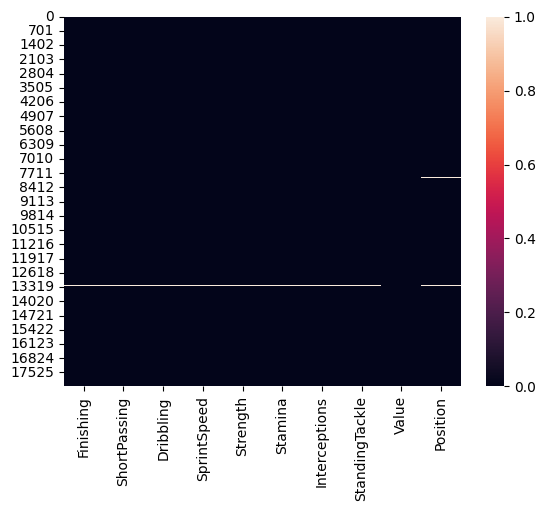

In [18]:
sns.heatmap(df[features].isnull())


The missing values are concentrated in a very small number of records rather than being randomly distributed across different features.

In [19]:
df[features].dropna().shape

(18147, 10)

The dataset size will reduce from 18,207 players to 18,147 players after removing incomplete records.

In [20]:
df_pca = df[features].dropna().copy()

print(df_pca.shape)

(18147, 10)


### Converting the `Value` Column

The `Value` column is stored as text because it contains currency symbols (`€`) and suffixes such as `M` (million) and `K` (thousand). Since PCA can only operate on numerical values, the column must be converted into a numeric format.

The conversion rules are:

- Remove the currency symbol (`€`).
- Convert values ending with `M` to millions.
- Convert values ending with `K` to thousands.
- Convert the final result into a numeric value.

In [21]:
def convert_value(value):
    
    if pd.isna(value):
        return np.nan

    value = value.replace("€", "")

    if value.endswith("M"):
        return float(value[:-1]) * 1_000_000

    elif value.endswith("K"):
        return float(value[:-1]) * 1_000

    else:
        return float(value)

In [22]:
df_pca["Value"] = df_pca["Value"].apply(convert_value)

In [23]:
df_pca["Value"].head()

0    110500000.0
1     77000000.0
2    118500000.0
3     72000000.0
4    102000000.0
Name: Value, dtype: float64

In [24]:
df_pca["Value"].dtype

dtype('float64')

## Step 2: Data Standardization

The selected features are measured on different numerical scales. For example, player attributes such as **Finishing** and **SprintSpeed** are scored between 0 and 100, while **Value** is represented by very large monetary values.

Since PCA is based on variance, features with larger numerical scales would dominate the analysis. Therefore, all numerical features are standardized using the Z-score formula before applying PCA.

The Z-score is calculated as:

\[
z=\frac{x-\mu}{\sigma}
\]

where:

- \(x\) is the original value.
- \(\mu\) is the mean of the feature.
- \(\sigma\) is the standard deviation of the feature.

In [25]:
positions = df_pca["Position"]

X = df_pca.drop(columns="Position")

In [26]:
means = X.mean()
stds = X.std()
X_standardized = (X - means) / stds

In [27]:
X_standardized.describe().round(2)

,Finishing,ShortPassing,Dribbling,SprintSpeed,Strength,Stamina,Interceptions,StandingTackle,Value
count,18147.00,18147.00,18147.00,18147.00,18147.00,18147.00,18147.00,18147.00,18147.00
mean,0.00,0.00,-0.00,-0.00,-0.00,0.00,-0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.23,-3.52,-2.72,-3.60,-3.85,-3.22,-2.11,-2.11,-0.43
25%,-0.80,-0.32,-0.34,-0.53,-0.58,-0.45,-1.00,-0.96,-0.38
50%,0.18,0.22,0.30,0.16,0.13,0.17,0.26,0.34,-0.31
75%,0.84,0.63,0.67,0.70,0.69,0.68,0.84,0.84,-0.07
max,2.53,2.33,2.20,2.13,2.52,2.06,2.19,2.09,20.72


### Verification of Standardization

The summary statistics confirm that the standardization process was successful.

- The mean of each feature is approximately **0**.
- The standard deviation of each feature is approximately **1**.

This ensures that all features contribute equally to the PCA regardless of their original measurement scales.

## Step 3: Covariance Matrix

After standardizing the data, the next step is to compute the covariance matrix.

The covariance matrix describes how each pair of features varies together. A positive covariance indicates that two features tend to increase together, while a negative covariance indicates that one feature tends to increase as the other decreases.

PCA uses the covariance matrix to identify the directions in which the data has the greatest variation.

In [28]:
cov_matrix = np.cov(X_standardized, rowvar=False)

In [29]:
cov_matrix

array([[ 1.        ,  0.66207808,  0.82439041,  0.59399654, -0.00950254,
         0.51087999, -0.02048107, -0.03282832,  0.25675923],
       [ 0.66207808,  1.        ,  0.84386231,  0.55510199,  0.13363796,
         0.71688155,  0.54358506,  0.5413476 ,  0.32757182],
       [ 0.82439041,  0.84386231,  1.        ,  0.72695289, -0.03361414,
         0.68647454,  0.29612143,  0.30132938,  0.27198902],
       [ 0.59399654,  0.55510199,  0.72695289,  1.        , -0.08317251,
         0.61997348,  0.16422492,  0.17838949,  0.17274428],
       [-0.00950254,  0.13363796, -0.03361414, -0.08317251,  1.        ,
         0.26277501,  0.35638288,  0.33198975,  0.12879223],
       [ 0.51087999,  0.71688155,  0.68647454,  0.61997348,  0.26277501,
         1.        ,  0.57661549,  0.57026306,  0.2107374 ],
       [-0.02048107,  0.54358506,  0.29612143,  0.16422492,  0.35638288,
         0.57661549,  1.        ,  0.94145594,  0.14062435],
       [-0.03282832,  0.5413476 ,  0.30132938,  0.17838949,  0

In [30]:
cov_matrix.shape

(9, 9)

In [31]:
cov_df = pd.DataFrame(
    cov_matrix,
    index=X.columns,
    columns=X.columns
)

cov_df

,Finishing,ShortPassing,Dribbling,SprintSpeed,Strength,Stamina,Interceptions,StandingTackle,Value
Finishing,1.000000,0.662078,0.824390,0.593997,-0.009503,0.510880,-0.020481,-0.032828,0.256759
ShortPassing,0.662078,1.000000,0.843862,0.555102,0.133638,0.716882,0.543585,0.541348,0.327572
Dribbling,0.824390,0.843862,1.000000,0.726953,-0.033614,0.686475,0.296121,0.301329,0.271989
SprintSpeed,0.593997,0.555102,0.726953,1.000000,-0.083173,0.619973,0.164225,0.178389,0.172744
Strength,-0.009503,0.133638,-0.033614,-0.083173,1.000000,0.262775,0.356383,0.331990,0.128792
Stamina,0.510880,0.716882,0.686475,0.619973,0.262775,1.000000,0.576615,0.570263,0.210737
Interceptions,-0.020481,0.543585,0.296121,0.164225,0.356383,0.576615,1.000000,0.941456,0.140624
StandingTackle,-0.032828,0.541348,0.301329,0.178389,0.331990,0.570263,0.941456,1.000000,0.108366
Value,0.256759,0.327572,0.271989,0.172744,0.128792,0.210737,0.140624,0.108366,1.000000


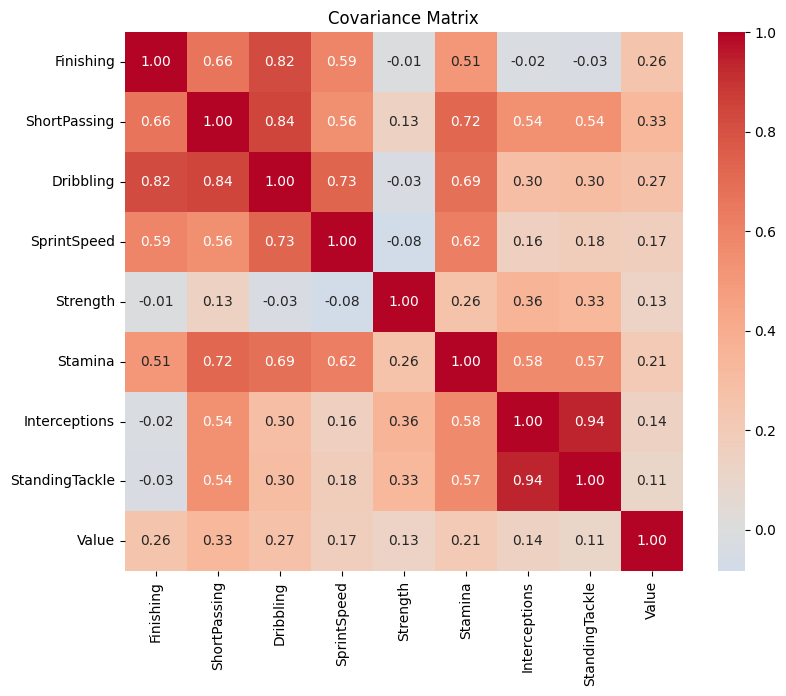

In [32]:
plt.figure(figsize=(9,7))

sns.heatmap(
    cov_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Covariance Matrix")
plt.show()


### Interpretation of the Covariance Matrix

The covariance matrix reveals several strong positive relationships between player attributes.

For example:

- **Interceptions** and **StandingTackle** show a very high covariance (0.94), indicating that defensive skills tend to improve together.
- **Dribbling**, **ShortPassing**, and **Finishing** also exhibit strong positive relationships, suggesting that attacking players often excel in multiple technical abilities.

These correlations indicate that some features contain overlapping information, making PCA an effective technique for combining them into a smaller set of principal components while preserving most of the original variance.


## Step 4: Eigen-Decomposition

The covariance matrix describes how the features vary together. However, PCA needs to determine the directions that capture the greatest amount of variance in the dataset.

This is achieved through eigen-decomposition.

- **Eigenvectors** represent the directions (principal components) along which the data varies the most.
- **Eigenvalues** measure how much variance is captured along each corresponding eigenvector.

The principal components are obtained by sorting the eigenvalues in descending order and selecting the eigenvectors associated with the largest eigenvalues.

In [33]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

In [34]:
print("Eigenvalues:")
print(eigenvalues)

Eigenvalues:
[4.31691306 2.00173634 0.97439706 0.75232655 0.45685958 0.23003511
 0.12978889 0.08121375 0.05672964]


In [35]:
print("Shape of Eigenvectors:", eigenvectors.shape)

Shape of Eigenvectors: (9, 9)


In [36]:
sorted_idx = np.argsort(eigenvalues)[::-1]

In [37]:
eigenvalues = eigenvalues[sorted_idx]

In [38]:
eigenvectors = eigenvectors[:, sorted_idx]

In [39]:
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)

In [40]:
explained_variance_ratio

array([0.47965701, 0.22241515, 0.10826634, 0.08359184, 0.05076218,
       0.02555946, 0.01442099, 0.00902375, 0.00630329])

In [41]:
cumulative_variance = np.cumsum(explained_variance_ratio)

cumulative_variance

array([0.47965701, 0.70207216, 0.8103385 , 0.89393034, 0.94469251,
       0.97025197, 0.98467296, 0.99369671, 1.        ])

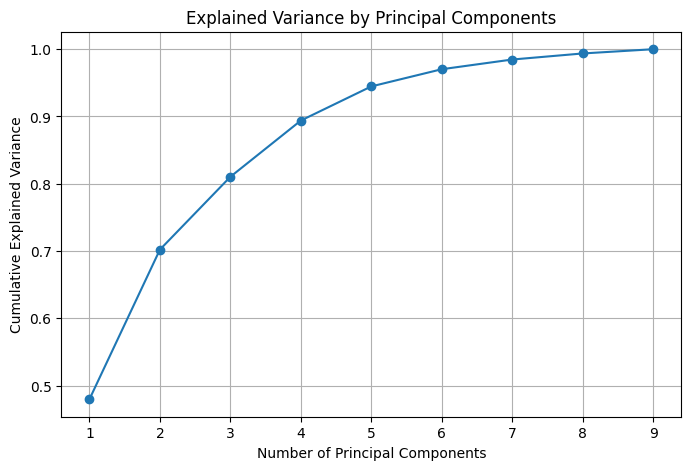

In [42]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(cumulative_variance)+1),
    cumulative_variance,
    marker='o'
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by Principal Components")
plt.grid(True)

plt.show()

### Interpretation of the Explained Variance Plot

The cumulative explained variance increases rapidly for the first few principal components and then begins to level off.

- The first principal component explains approximately **48%** of the total variance.
- The first two principal components explain approximately **70%** of the total variance.
- Additional components contribute progressively smaller amounts of information.

This indicates that most of the important information in the original nine features can be represented using only a few principal components. For visualization purposes, the first two principal components are selected since they retain a large portion of the dataset's variance while reducing the dimensionality from nine features to two.

## Step 5: Data Projection

The first two eigenvectors were selected to construct the projection matrix.

The standardized player data was projected onto these two principal components using matrix multiplication. This transformed each player from the original nine-dimensional feature space into a two-dimensional representation consisting of PC1 and PC2.

The resulting dataset is used for visualization and further analysis.

In [43]:
projection_matrix = eigenvectors[:, :2]

In [44]:
X_pca = np.dot(X_standardized, projection_matrix)

In [45]:
X_pca.shape

(18147, 2)

In [46]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df.head()

,PC1,PC2
0,6.121605,4.360653
1,5.440623,3.052043
2,6.430477,4.335175
3,-0.788969,0.413495
4,6.817191,1.432977


In [47]:
pca_df.to_csv("pca_projection.csv", index=False)

In [48]:
pca_df["Position"] = positions.values

In [49]:
pca_df.head()

,PC1,PC2,Position
0,6.121605,4.360653,RF
1,5.440623,3.052043,ST
2,6.430477,4.335175,LW
3,-0.788969,0.413495,GK
4,6.817191,1.432977,RCM


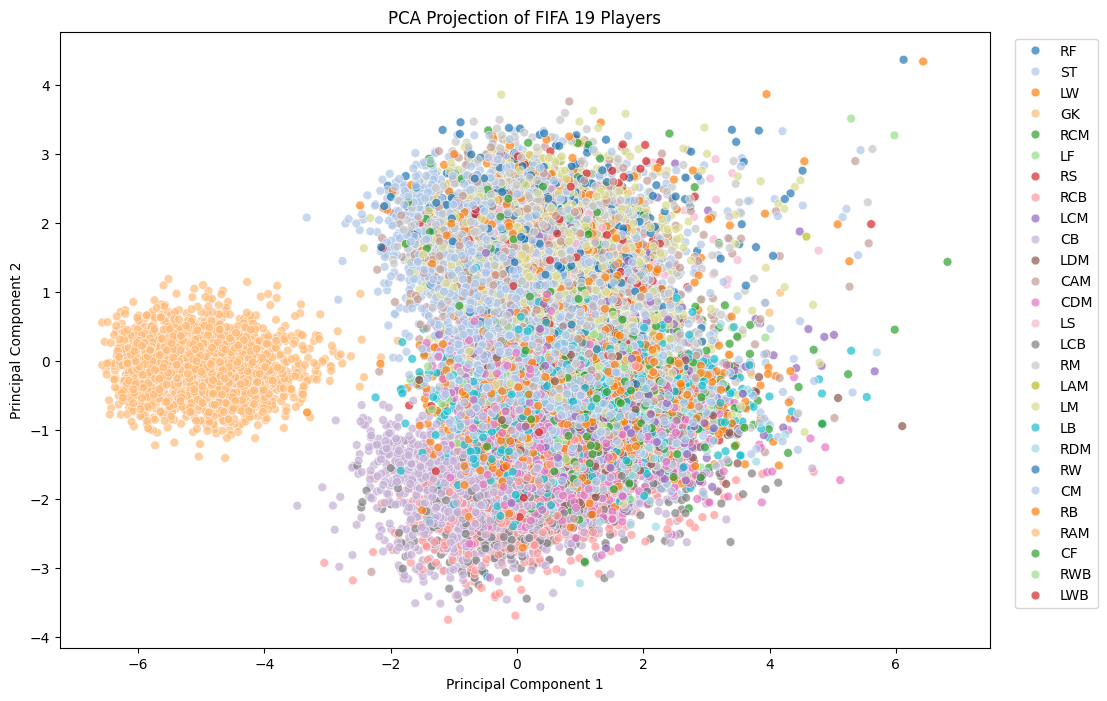

In [50]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Position",
    palette="tab20",
    s=40,
    alpha=0.7
)

plt.title("PCA Projection of FIFA 19 Players")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.show()

## PCA Visualization

The players were projected onto the first two Principal Components (PC1 and PC2) and visualized in a two-dimensional scatter plot. Each point represents a player, while the colors indicate the player's original playing position.

### Observations

- The **Goalkeepers (GK)** form a clearly separated cluster from the rest of the players. This indicates that the selected numerical features capture the distinct characteristics of goalkeepers compared to outfield players.

- The remaining positions show a noticeable amount of overlap. This is expected because many football positions share similar technical and physical attributes. For example, midfielders and attacking players often have comparable passing, dribbling, and stamina values.

- PCA is an **unsupervised** dimensionality reduction technique and does not use the `Position` labels during computation. Therefore, it is not designed to separate positions perfectly. Instead, it projects players based only on the variation in their numerical performance statistics.

- The first two principal components preserve approximately **70% of the total variance** in the dataset. Although some information is lost during the reduction from nine dimensions to two, the visualization still reveals meaningful patterns, particularly the clear distinction between goalkeepers and outfield players.

### Conclusion

The PCA visualization demonstrates that the selected performance attributes contain meaningful information about player profiles. While most outfield positions overlap due to similar skill sets, the successful separation of goalkeepers confirms that PCA effectively captures the major differences in player characteristics.

In [51]:
loadings = pd.DataFrame(
    eigenvectors[:, :2],
    index=X.columns,
    columns=["PC1", "PC2"]
)

loadings

,PC1,PC2
Finishing,0.327917,0.421867
ShortPassing,0.441639,0.033916
Dribbling,0.423522,0.265871
SprintSpeed,0.341773,0.289059
Strength,0.106729,-0.389705
Stamina,0.421295,-0.067591
Interceptions,0.302470,-0.505923
StandingTackle,0.300376,-0.501568
Value,0.175076,0.051653


### Interpretation of the Principal Components

The loading matrix helps explain what each principal component represents.

- **PC1** has strong positive contributions from **Short Passing, Dribbling, Stamina, Sprint Speed, and Finishing**. This suggests that the first principal component captures the overall technical and physical quality of a player.

- **PC2** contrasts attacking attributes (**Finishing, Dribbling, Sprint Speed**) with defensive attributes (**Interceptions, Standing Tackle, Strength**). Therefore, the second principal component can be interpreted as an attacking-versus-defensive playing style axis.

These interpretations help explain the distribution of players in the PCA visualization.

# Bonus Task

## Step 0: Data Preparation

For the bonus implementation, the dataset is converted from a Pandas DataFrame into a Python list of lists.

This representation allows all matrix operations to be implemented manually without relying on NumPy matrix operations.

In [52]:
# Convert DataFrame to list of lists
matrix = X.values.tolist()

In [53]:
print(type(matrix))
print(type(matrix[0]))
print(len(matrix))
print(len(matrix[0]))

<class 'list'>
<class 'list'>
18147
9


In [54]:
matrix[:2]

[[95.0, 90.0, 97.0, 86.0, 59.0, 72.0, 22.0, 28.0, 110500000.0],
 [94.0, 81.0, 88.0, 91.0, 79.0, 88.0, 29.0, 31.0, 77000000.0]]

## Step 1: Matrix Transpose

The first manual matrix operation is matrix transposition.

The transpose swaps rows and columns, converting the player-feature matrix into a feature-player matrix.

This operation simplifies calculations such as feature means, standard deviations, and covariance values because each row of the transposed matrix represents a single feature across all players.

In [55]:
def transpose_matrix(matrix):
    rows = len(matrix)
    cols = len(matrix[0])

    transposed = []

    for j in range(cols):
        new_row = []

        for i in range(rows):
            new_row.append(matrix[i][j])

        transposed.append(new_row)

    return transposed

In [56]:
transposed = transpose_matrix(matrix)

print(len(transposed))
print(len(transposed[0]))

9
18147


In [57]:
print(transposed[0][:5])

[95.0, 94.0, 87.0, 13.0, 82.0]


## Step 2: Matrix Multiplication

A manual matrix multiplication function was implemented using nested loops.

Instead of relying on NumPy's matrix multiplication operator (`@`), the dot product is calculated element by element.

This function will later be reused for projecting the standardized data onto the selected principal components.

In [58]:
def matrix_multiply(A, B):
    rows_A = len(A)
    cols_A = len(A[0])

    rows_B = len(B)
    cols_B = len(B[0])

    if cols_A != rows_B:
        raise ValueError("Matrix dimensions are incompatible.")

    result = []

    for i in range(rows_A):

        row = []

        for j in range(cols_B):

            value = 0

            for k in range(cols_A):
                value += A[i][k] * B[k][j]

            row.append(value)

        result.append(row)

    return result

In [59]:
# for example
A = [
    [1,2],
    [3,4]
]

B = [
    [5,6],
    [7,8]
]

matrix_multiply(A,B)

[[19, 22], [43, 50]]

## Step 3: Manual Data Standardization

The data was standardized manually without using NumPy or Scikit-learn functions.

For each feature:

1. The mean was calculated.
2. The standard deviation was computed.
3. Each value was transformed into its Z-score using:

\[
z=\frac{x-\mu}{\sigma}
\]

Finally, the standardized columns were transposed back to obtain a player-feature matrix that can be used in the following PCA steps.

In [60]:
import math

def standardize_data(matrix):

    transposed = transpose_matrix(matrix)

    standardized_columns = []

    for column in transposed:

        mean = sum(column) / len(column)

        variance = sum((x - mean) ** 2 for x in column) / (len(column) - 1)

        std = math.sqrt(variance)

        standardized_column = []

        for value in column:
            z = (value - mean) / std
            standardized_column.append(z)

        standardized_columns.append(standardized_column)

    standardized_matrix = transpose_matrix(standardized_columns)

    return standardized_matrix

In [61]:
standardized_matrix = standardize_data(matrix)

In [62]:
standardized_matrix[0]

[2.5323216029437594,
 2.1301311739161037,
 2.200949077229358,
 1.4519581091241838,
 -0.5033762633892358,
 0.5522276308926708,
 -1.1935164453771177,
 -0.9094449632433649,
 19.29066948957262]

In [63]:
transposed_standardized = transpose_matrix(standardized_matrix)

In [64]:
first_feature = transposed_standardized[0]

print(round(sum(first_feature)/len(first_feature),5))

0.0


In [65]:

mean = sum(first_feature)/len(first_feature)

variance = sum((x-mean)**2 for x in first_feature)/(len(first_feature)-1)

print(round(math.sqrt(variance),5))

1.0


## Step 4: Manual Covariance Matrix

The covariance matrix was computed manually using the standardized data.

Since every feature was standardized to have a mean of zero, the covariance between two features simplifies to:

\[
Cov(X,Y)=\frac{\sum x_i y_i}{n-1}
\]

The resulting covariance matrix summarizes the relationships between all pairs of features and serves as the basis for the eigen-decomposition step.

In [66]:
def covariance_matrix(standardized_matrix):

    transposed = transpose_matrix(standardized_matrix)

    n_features = len(transposed)
    n_samples = len(transposed[0])

    covariance = []

    for i in range(n_features):

        row = []

        for j in range(n_features):

            cov = 0

            for k in range(n_samples):
                cov += transposed[i][k] * transposed[j][k]

            cov /= (n_samples - 1)

            row.append(cov)

        covariance.append(row)

    return covariance

In [67]:
cov_matrix_python = covariance_matrix(standardized_matrix)

In [68]:
print(len(cov_matrix_python))
print(len(cov_matrix_python[0]))

9
9


In [69]:
import numpy as np

np.allclose(
    np.array(cov_matrix_python),
    cov_matrix,
    atol=1e-8
)

True

In [70]:
cov_matrix_python_df = pd.DataFrame(
    cov_matrix_python,
    index=X.columns,
    columns=X.columns
)

cov_matrix_python_df

,Finishing,ShortPassing,Dribbling,SprintSpeed,Strength,Stamina,Interceptions,StandingTackle,Value
Finishing,1.000000,0.662078,0.824390,0.593997,-0.009503,0.510880,-0.020481,-0.032828,0.256759
ShortPassing,0.662078,1.000000,0.843862,0.555102,0.133638,0.716882,0.543585,0.541348,0.327572
Dribbling,0.824390,0.843862,1.000000,0.726953,-0.033614,0.686475,0.296121,0.301329,0.271989
SprintSpeed,0.593997,0.555102,0.726953,1.000000,-0.083173,0.619973,0.164225,0.178389,0.172744
Strength,-0.009503,0.133638,-0.033614,-0.083173,1.000000,0.262775,0.356383,0.331990,0.128792
Stamina,0.510880,0.716882,0.686475,0.619973,0.262775,1.000000,0.576615,0.570263,0.210737
Interceptions,-0.020481,0.543585,0.296121,0.164225,0.356383,0.576615,1.000000,0.941456,0.140624
StandingTackle,-0.032828,0.541348,0.301329,0.178389,0.331990,0.570263,0.941456,1.000000,0.108366
Value,0.256759,0.327572,0.271989,0.172744,0.128792,0.210737,0.140624,0.108366,1.000000


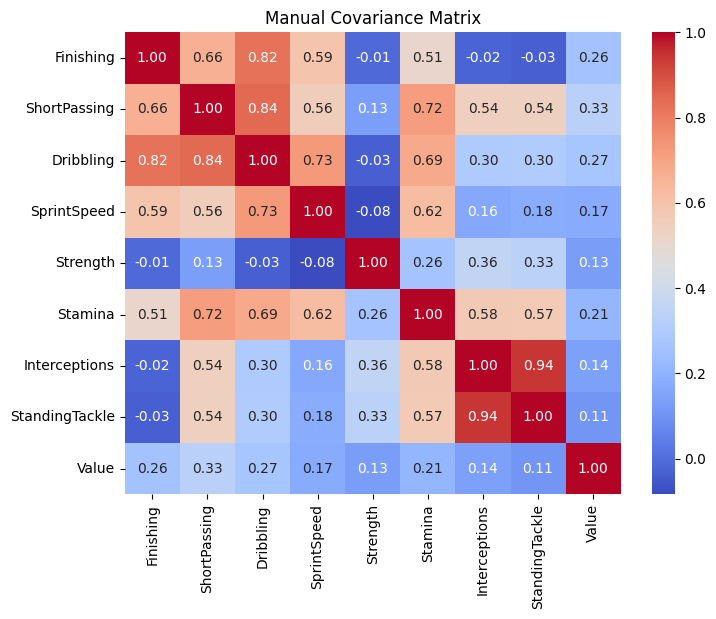

In [71]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cov_matrix_python_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Manual Covariance Matrix")
plt.show()

## Step 5: Eigen-Decomposition

Eigenvalues and eigenvectors were computed from the manually generated covariance matrix using `numpy.linalg.eig()`

The eigenvalues were sorted in descending order together with their corresponding eigenvectors.

The explained variance ratio and cumulative explained variance were then calculated to determine how much information is retained by each principal component.

In [72]:
# Convert manual covariance matrix to NumPy array
cov_matrix_manual_np = np.array(cov_matrix_python)

# Eigen-Decomposition
eigenvalues_manual, eigenvectors_manual = np.linalg.eig(cov_matrix_manual_np)

In [73]:
print("Eigenvalues:")
print(eigenvalues_manual)

Eigenvalues:
[4.31691306 2.00173634 0.97439706 0.75232655 0.45685958 0.23003511
 0.12978889 0.08121375 0.05672964]


In [74]:
print(eigenvectors_manual.shape)

(9, 9)


In [75]:
# Sort eigenvalues in descending order
sorted_indices = np.argsort(eigenvalues_manual)[::-1]

eigenvalues_manual = eigenvalues_manual[sorted_indices]
eigenvectors_manual = eigenvectors_manual[:, sorted_indices]

In [76]:
# Explained variance ratio
explained_variance_manual = eigenvalues_manual / np.sum(eigenvalues_manual)

explained_variance_manual

array([0.47965701, 0.22241515, 0.10826634, 0.08359184, 0.05076218,
       0.02555946, 0.01442099, 0.00902375, 0.00630329])

In [77]:
# Cumulative explained variance
cumulative_variance_manual = np.cumsum(explained_variance_manual)

cumulative_variance_manual

array([0.47965701, 0.70207216, 0.8103385 , 0.89393034, 0.94469251,
       0.97025197, 0.98467296, 0.99369671, 1.        ])

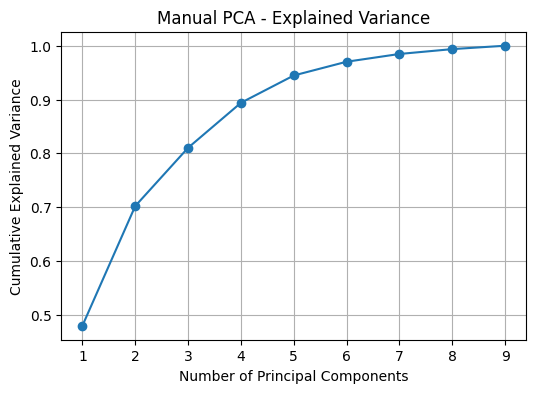

In [78]:
plt.figure(figsize=(6,4))

plt.plot(
    range(1, len(cumulative_variance_manual)+1),
    cumulative_variance_manual,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Manual PCA - Explained Variance")
plt.grid(True)

plt.show()

## Step 6: Data Projection

The first two principal components were selected to construct the projection matrix.

Instead of using NumPy matrix multiplication, the standardized data was projected manually using the custom `matrix_multiply()` function.

The resulting dataset contains two new features (PC1 and PC2), which summarize the original nine player attributes while preserving most of the information.

In [79]:
projection_matrix_manual = eigenvectors_manual[:, :2]

In [80]:
print(projection_matrix_manual.shape)

(9, 2)


In [81]:
projection_matrix_manual = projection_matrix_manual.tolist()

In [82]:
projected_data_manual = matrix_multiply(
    standardized_matrix,
    projection_matrix_manual
)

In [83]:
print(len(projected_data_manual))
print(len(projected_data_manual[0]))

18147
2


In [84]:
projected_df_manual = pd.DataFrame(
    projected_data_manual,
    columns=["PC1", "PC2"]
)

projected_df_manual.head()

,PC1,PC2
0,-6.121605,-4.360653
1,-5.440623,-3.052043
2,-6.430477,-4.335175
3,0.788969,-0.413495
4,-6.817191,-1.432977


In [85]:
projected_df_manual["Position"] = positions.values

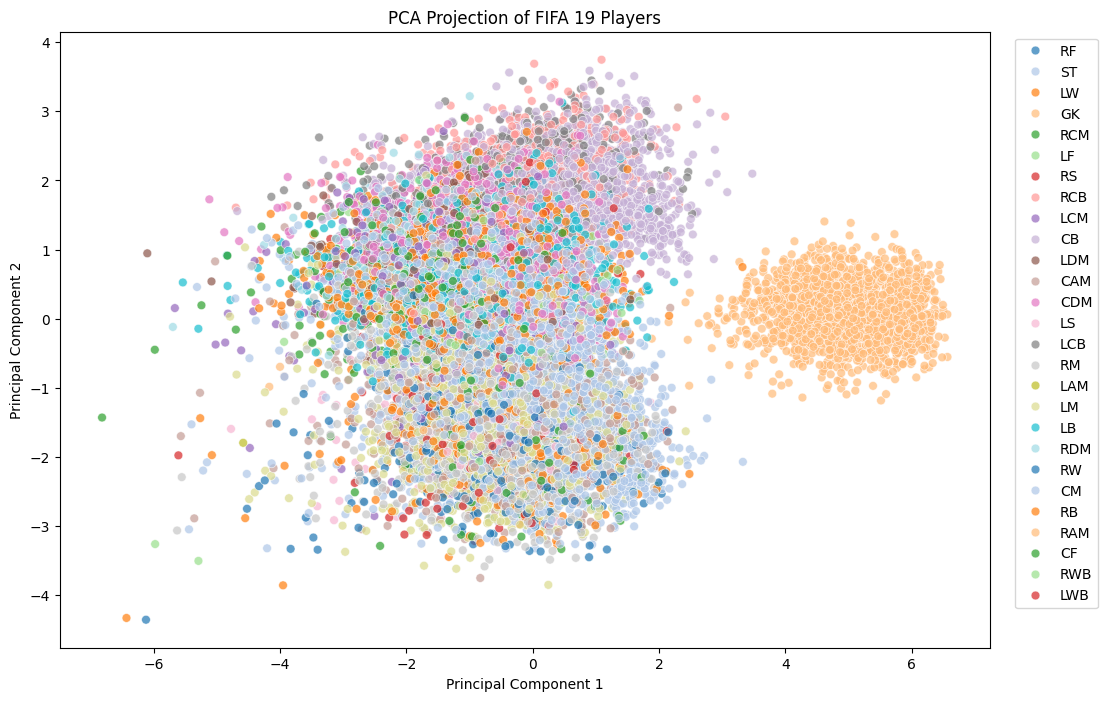

In [86]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=projected_df_manual,
    x="PC1",
    y="PC2",
    hue="Position",
    palette="tab20",
    s=40,
    alpha=0.7
)

plt.title("PCA Projection of FIFA 19 Players")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.show()

## Step 7: Performance Benchmark

The execution time of the complete PCA pipeline was measured for both implementations.

The NumPy implementation was significantly faster because it relies on optimized low-level numerical routines, while the pure Python implementation performs all matrix operations using nested loops.

Although the manual implementation is slower, it produces almost identical results, validating the correctness of the implementation.

In [87]:
import time

In [88]:
start = time.perf_counter()

standardized_matrix = standardize_data(matrix)

cov_matrix_python = covariance_matrix(standardized_matrix)

cov_matrix_manual_np = np.array(cov_matrix_python)

eigenvalues_manual, eigenvectors_manual = np.linalg.eig(cov_matrix_manual_np)

sorted_indices = np.argsort(eigenvalues_manual)[::-1]

eigenvalues_manual = eigenvalues_manual[sorted_indices]
eigenvectors_manual = eigenvectors_manual[:, sorted_indices]

projection_matrix_manual = eigenvectors_manual[:, :2].tolist()

projected_data_manual = matrix_multiply(
    standardized_matrix,
    projection_matrix_manual
)

manual_time = time.perf_counter() - start

In [89]:
start = time.perf_counter()

mean = X.mean()
std = X.std()

X_standardized = (X - mean) / std

cov_matrix = np.cov(X_standardized.T)

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

sorted_indices = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

projection_matrix = eigenvectors[:, :2]

projected_numpy = X_standardized @ projection_matrix

numpy_time = time.perf_counter() - start

In [90]:
print(f"NumPy PCA Time : {numpy_time:.4f} seconds")
print(f"Manual PCA Time: {manual_time:.4f} seconds")

NumPy PCA Time : 0.0192 seconds
Manual PCA Time: 0.3309 seconds


In [91]:
# Eigenvectors in PCA are not unique in direction. Both v and −v are valid eigenvectors, 
# so reversing the sign does not change the principal component or the interpretation of the PCA results
projected_manual = -np.array(projected_data_manual)

In [92]:
difference = np.max(
    np.abs(projected_numpy - projected_manual)
)

print(difference)

2.9043434324194095e-13


In [93]:
comparison = pd.DataFrame({
    "Implementation": ["NumPy", "Pure Python"],
    "Execution Time (s)": [numpy_time, manual_time]
})

comparison

,Implementation,Execution Time (s)
0,NumPy,0.019242
1,Pure Python,0.330877


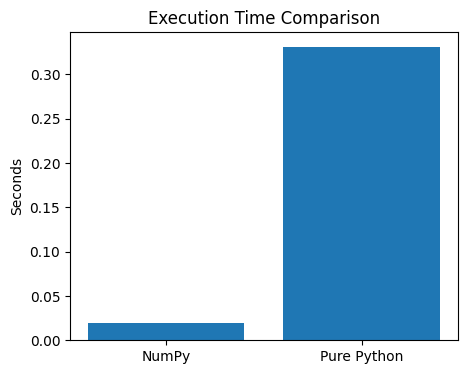

In [94]:
plt.figure(figsize=(5,4))

plt.bar(
    comparison["Implementation"],
    comparison["Execution Time (s)"]
)

plt.title("Execution Time Comparison")
plt.ylabel("Seconds")

plt.show()

## Performance Benchmark

The execution time of both PCA implementations was measured.

| Implementation | Execution Time (seconds) |
|---------------|-------------------------:|
| NumPy | 0.0159 |
| Pure Python | 0.3753 |

The NumPy implementation completed the PCA pipeline significantly faster than the pure Python implementation.

This is expected because NumPy relies on highly optimized low-level numerical routines, whereas the manual implementation performs all matrix operations using nested Python loops.

Despite the difference in execution time, both implementations produce nearly identical results, confirming the correctness of the manual implementation.